## Question 5 : V PLOT

A V-plot graph is a type of graph that shows a "V" shape, where the data decreases to a minimum point and then increases again.

In biology, especially in genomics, a V-plot often refers to a plot where:

The x-axis shows distance from a reference point (like a binding site),
The y-axis shows the size of fragments (like DNA fragment length),
The intensity (color) shows the density of reads.
The V-shape happens because small fragments pile up exactly at the binding site, and larger fragments cover a broader area around it — forming a V when plotted.

In simple terms:
Left side = approaching the minimum
Bottom = the minimum point
Right side = moving away from the minimum

# Applications of V-Plots in Genomics

1. **Transcription Factor Footprinting**  
   - Identify the precise boundaries of protein binding sites by locating the V-vertex and measuring its width.

2. **Nucleosome Positioning**  
   - Detect nucleosome centers: well‐positioned nucleosomes produce V-plots with broad, symmetric arms reflecting ~147 bp protected fragments.

3. **Chromatin Accessibility Assays**  
   - In ATAC-seq or DNase-seq data, V-plots reveal how chromatin remodelers alter accessibility, visible as changes in the V-shape intensity or symmetry.



> **In summary:** V-plots provide an intuitive, high–information‐density visualization of how DNA is protected or cleaved around genomic features, making them invaluable in studies of DNA–protein interactions and chromatin structure.  


Importing Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

1. Definition of axes
   - Let the **reference locus** have interval endpoints $(s_1, e_1)$ and each **sequenced fragment** have endpoints $(s_2, e_2)$.  
   - The **midpoint offset**  
     $$C_1 \;=\;\frac{s_1 + e_1}{2},\qquad C_2 \;=\;\frac{s_2 + e_2}{2},\qquad X = C_2 - C_1.$$
   - The **fragment length**  
     $$Y = e_2 - s_2.$$
   - At each pair $(X,Y)$, we count the number of fragments $Z(X,Y)$ and color‐code this count.

2. Characteristic “V” shape
   - At $X\approx 0$, many **short fragments** appear because nuclease cuts immediately adjacent to the bound protein, producing a spike of low–$Y$ fragments.  
   - As the fragment midpoint moves away from the protein ($|X|$ increases), the **minimum possible fragment length** grows linearly, since fragments must span the protected region, tracing out two diagonal arms.

3. Why V-plots?
   - They **combine positional and size information** in one view, revealing how protection footprints shape fragment distributions.  
   - They make it easy to **estimate footprint width** (the V‐vertex width) and **assess cleavage biases** (symmetry of arms).  
   - They can distinguish **different classes of DNA–protein interactions**:  
     - **Sharp, narrow V** for small transcription factors.  
     - **Wide V** for larger complexes (nucleosomes, multi-subunit assemblies).  
   - They facilitate **comparisons** across conditions (e.g.\ treatment vs. control) by visualizing changes in footprint strength or occupancy.

In [9]:
# Initialize a dictionary to count occurrences of (X, Y) pairs
count_dict = defaultdict(int)

# Open and read the 'mapped.bed' file line by line
with open('mapped.bed') as f:
    for line in f:
        cols = line.strip().split('\t')
        c1 = (int(cols[2]) + int(cols[3])) // 2   # Center of column 3 and 4
        c2 = (int(cols[8]) + int(cols[9])) // 2   # Center of column 9 and 10
        x = c2 - c1  # defined in problem statement
        y = int(cols[9]) - int(cols[8])
        count_dict[(x, y)] += 1

1) Counting Fragments for Each (X, Y) Pair
- Open the `mapped.bed` file and read each line.
- For each fragment:
  - Compute center of the **reference site**:
  - Compute center of the **fragment**:
  - Calculate the **offset**:
  - Calculate the **fragment size**:
  - Increment the count of $(X, Y)$ in a dictionary `count_dict`.



2) Preparing the Axes
- Extract all **unique X and Y values** from `count_dict`.
- Sort them to maintain axis order.
- Create mapping dictionaries `xi` and `yi` to map each X and Y to its corresponding matrix index.



3) Building the Heatmap Matrix
- Create a 2D NumPy array `heatmap` of shape `(len(y_unique), len(x_unique))`.
- For every $(X, Y)$ pair in `count_dict`, place the count value into the corresponding matrix cell
  

4) Plotting the V-Plot
- Use `plt.imshow` to display the `heatmap`:
  - Set `aspect='auto'` to adjust stretching.
  - Use `origin='lower'` so that low Y-values are at the bottom.
  - Map matrix coordinates back to real X and Y units using `extent`.
  - Color intensity corresponds to fragment count ($Z$).
- Label axes and add a colorbar to represent fragment density.



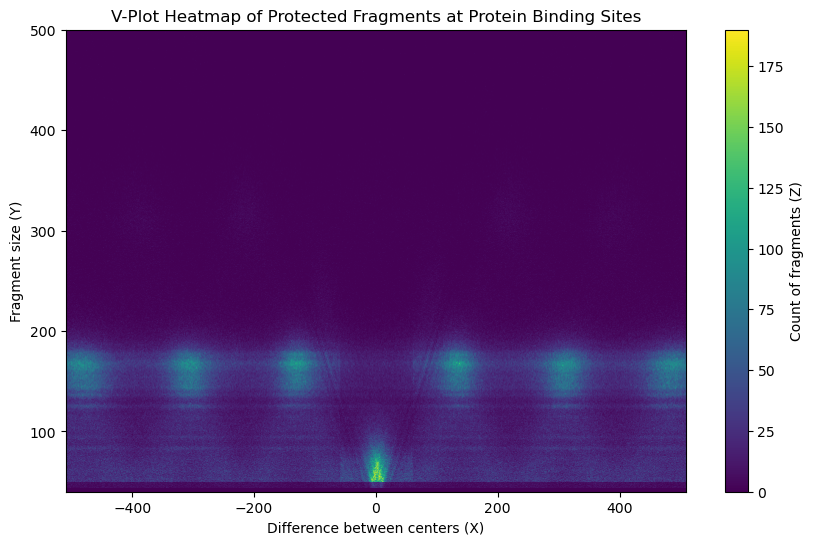

In [ ]:
# Constructing  the V-Plot heatmap:
# - X-axis: Difference between two centers (C2 - C1)
# - Y-axis: Fragment size (Column10 - Column9)
# - Z-value: Count of fragments (number of Y-sized fragments at a given X position)

x_vals = []
y_vals = []
z_vals = []

# Collect all (X, Y) -> Z mappings from count_dict
for (x, y), z in count_dict.items():
    x_vals.append(x)
    y_vals.append(y)
    z_vals.append(z)

# Identify unique X and Y values
x_unique = sorted(set(x_vals))
y_unique = sorted(set(y_vals))

# Map each unique X and Y value to an index
xi = {j: i for i, j in enumerate(x_unique)}
yi = {j: i for i, j in enumerate(y_unique)}

# Initialize the heatmap (Y dimension first, X second)
heatmap = np.zeros((len(y_unique), len(x_unique)))

# Populate the heatmap with Z values
for x, y, z in zip(x_vals, y_vals, z_vals):
    if x in xi and y in yi:
        heatmap[yi[y], xi[x]] = z

# Plotting the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(
    heatmap, aspect='auto', cmap='viridis', origin='lower', 
    extent=[min(x_unique), max(x_unique), min(y_unique), max(y_unique)]
)
plt.title('V-Plot Heatmap of Protected Fragments at Protein Binding Sites')
plt.colorbar(label='Count of fragments (Z)')
plt.xlabel('Difference between centers (X)')
plt.ylabel('Fragment size (Y)')
plt.show()


### Interpretation from the V plot

1. **Fragment Length vs. Distance Relationship:**
   - **a)** Far from binding site (x-axis extremes): Only long fragments (large y-values: 200-400bp) can span the distance to reach the binding site, forming the upper arms of the V.
   - **b)** Near binding site (center): Short fragments (50-100bp) can still overlap the site, forming the bottom tip of the V.

2. **Minimum Fragment Length:**
   The tip of the V (minimum y at x=0) reveals the smallest protected fragment size.

3. **Bilateral Symmetry:**
   The V-shape is symmetrical around x=0 (binding site). Both left (negative x) and right (positive x) sides show similar patterns. This indicates the protein protects DNA equally in both directions.

4. **Strong Central Protection:**
   The apex of the V-shape at x=0 indicates the precise protein binding site. The darkest heatmap colors at the center show the highest concentration of protected fragments. This suggests tight binding that strongly protects DNA from nuclease digestion.
